In [1]:
import pandas as pd
read_file =r"C:\Users\syedb\Desktop\Equinox Quantitative Analytics and Predictive Platform\data\features\AAPL_1h_features.csv"
df = pd.read_csv(read_file)        
df[['Open','High','Low','Close']].describe()

,Open,High,Low,Close
count,1635.000000,1635.000000,1635.000000,1635.000000
mean,235.092390,235.984848,234.217267,235.075775
std,29.078152,28.998319,29.117135,29.100087
min,172.770004,173.440002,169.210098,172.179001
25%,209.179955,210.105003,208.434998,209.159996
50%,230.850006,231.455002,230.350006,230.860001
75%,262.555008,263.454987,261.904999,262.785004
max,287.340515,288.609985,285.899994,287.320007


In [2]:
import pandas as pd

# 1. Use .loc to avoid the 'SettingWithCopyWarning'
# 2. Use shift(-1) to look at the NEXT row's price
df.loc[:, 'target'] = (df['Close'].shift(-1) > df['Close']).astype(int)

# 3. Drop the last row (it will always be 0/NaN because there's no "next" day)
df = df.dropna(subset=['target']).copy()

# 4. CRITICAL: In Pandas 2.0+, you MUST specify numeric_only=True 
# if your dataframe contains strings/dates (like 'Ticker' or 'Date')
print(df.groupby('target').mean(numeric_only=True))

              Open        High         Low       Close        Volume  \
target                                                                 
0       235.354664  236.606042  234.853225  236.133359  5.344337e+06   
1       234.832988  235.370455  233.588273  234.029769  5.801508e+06   

              ADX    DI_plus   DI_minus       ATR  Ichimoku_conversion  \
target                                                                   
0       29.417764  19.200423  19.238680  2.232773           236.048165   
1       28.846417  20.889315  17.952802  2.230153           234.095473   

        Ichimoku_base  Ichimoku_spanA  Ichimoku_spanB  Ichimoku_lagging  
target                                                                   
0          235.765867      235.359766      234.660495        236.098629  
1          233.853590      233.375118      232.741117        235.550138  


In [3]:
import pandas as pd

# 1. Ensure 'target' is created correctly
# Using .shift(-1) moves tomorrow's price to today's row
df.loc[:, 'target'] = (df['Close'].shift(-1) > df['Close']).astype(int)

# 2. Clean up the NaN row created by the shift
df = df.dropna(subset=['target']).copy()

# 3. FIX: Add 'numeric_only=True' to the correlation method
# This prevents errors if you have Date or Text columns
correlations = df.corr(numeric_only=True)['target'].sort_values(ascending=False)

print(correlations)

target                 1.000000
DI_plus                0.110665
Volume                 0.050065
ATR                   -0.001389
Open                  -0.008973
Ichimoku_lagging      -0.009394
High                  -0.021311
Low                   -0.021728
ADX                   -0.028533
Ichimoku_base         -0.033270
Ichimoku_conversion   -0.033729
Ichimoku_spanB        -0.034167
Ichimoku_spanA        -0.034919
Close                 -0.036155
DI_minus              -0.086490
Name: target, dtype: float64


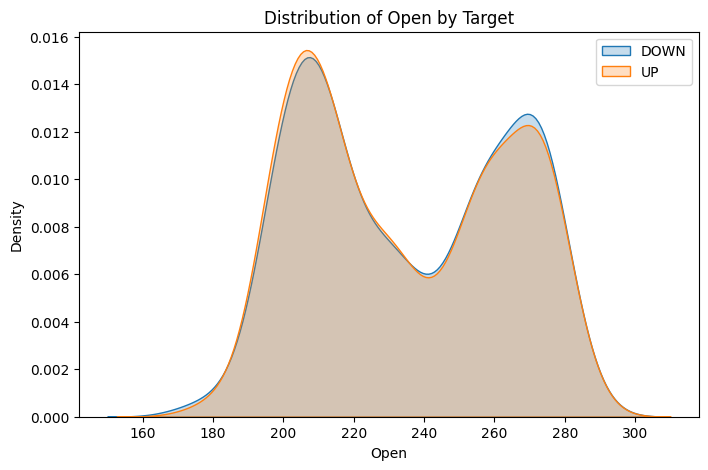

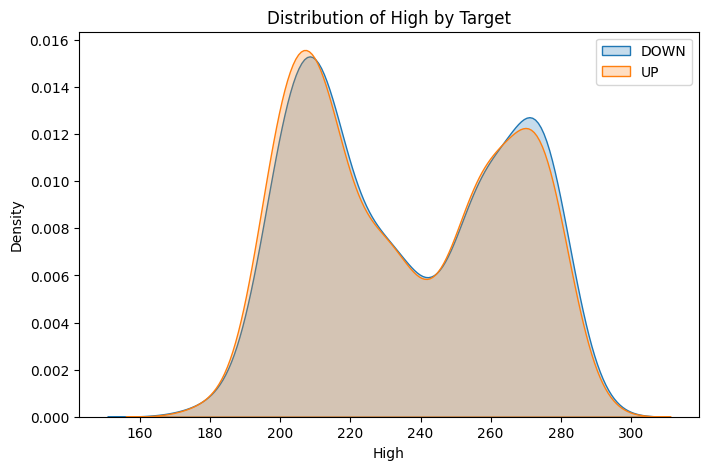

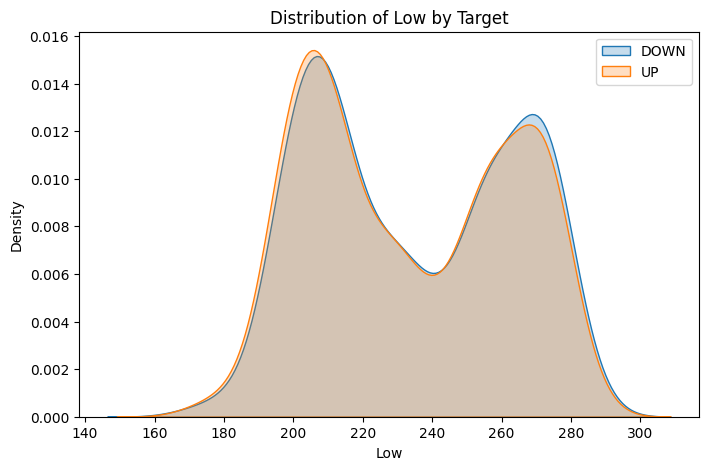

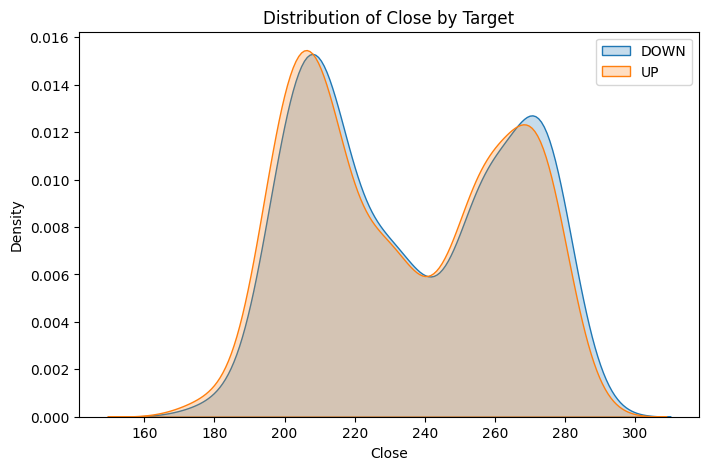

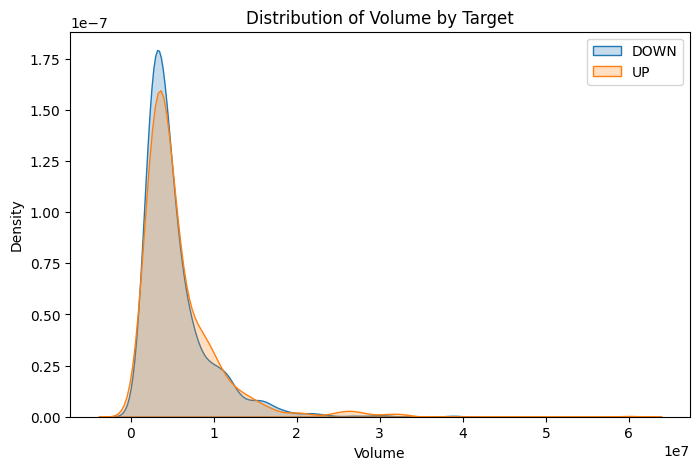

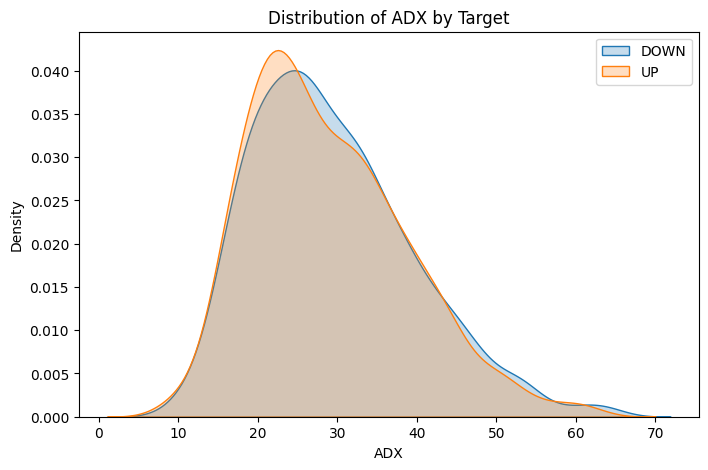

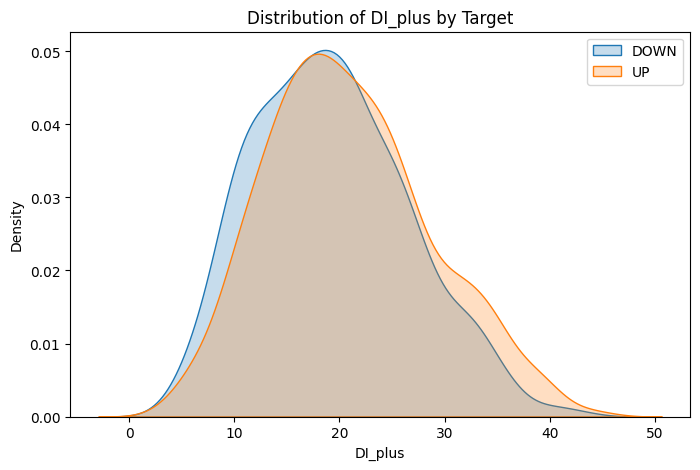

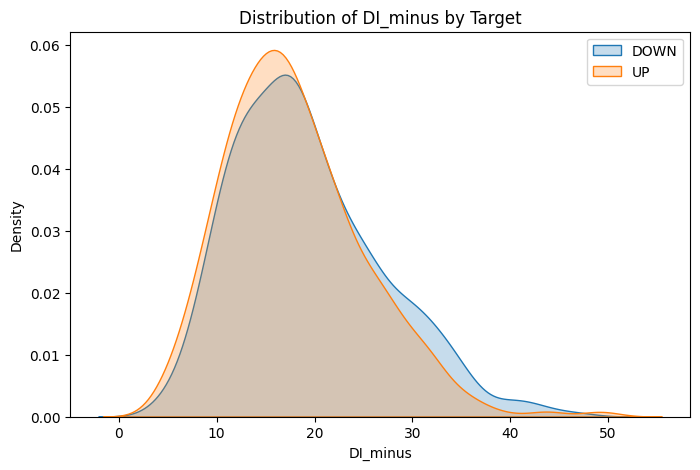

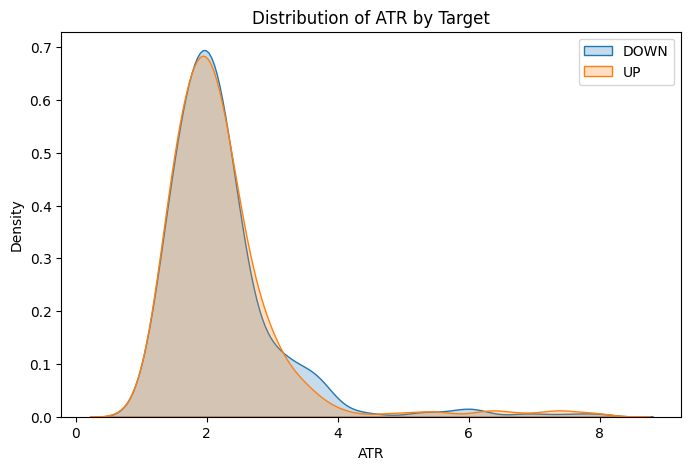

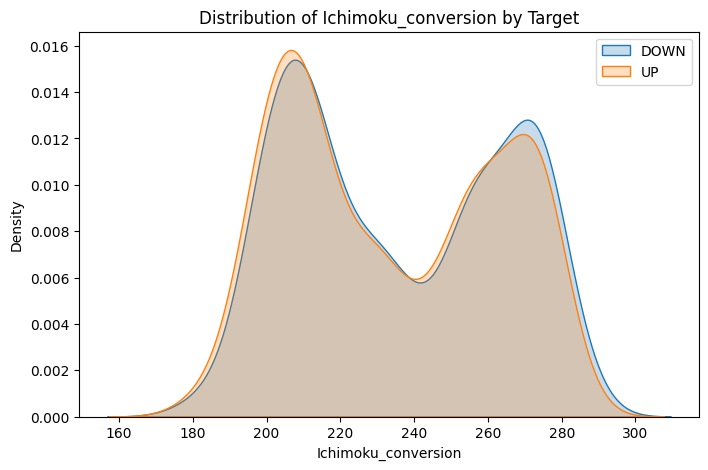

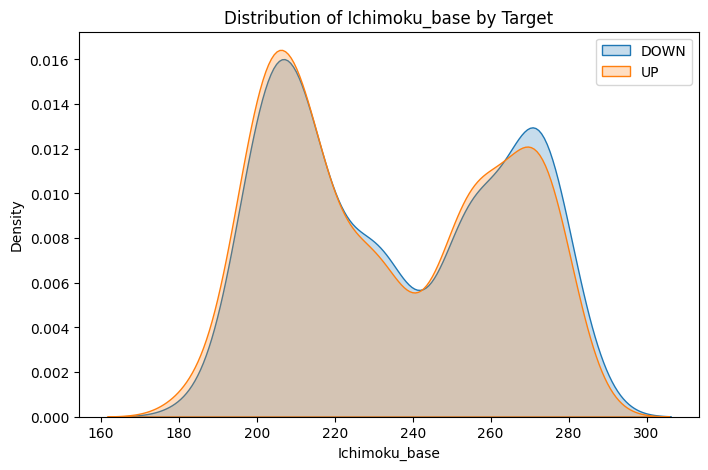

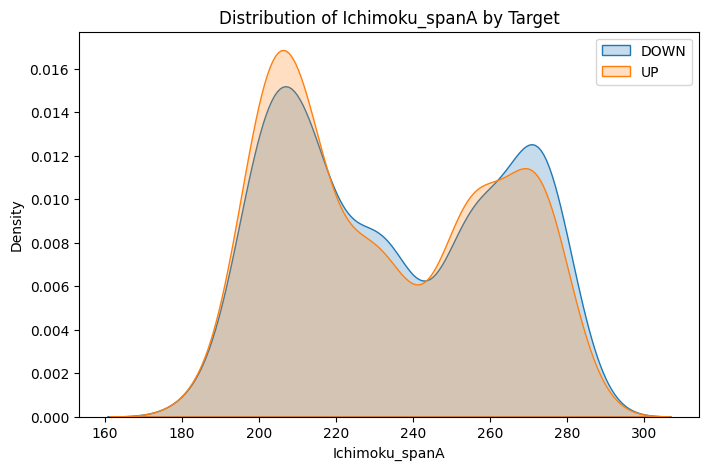

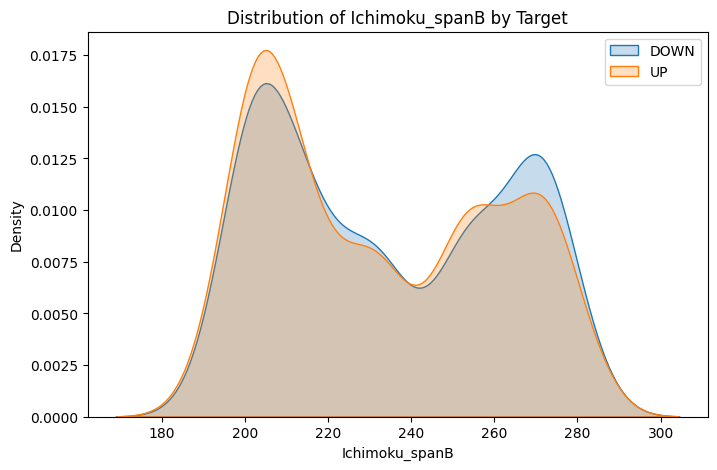

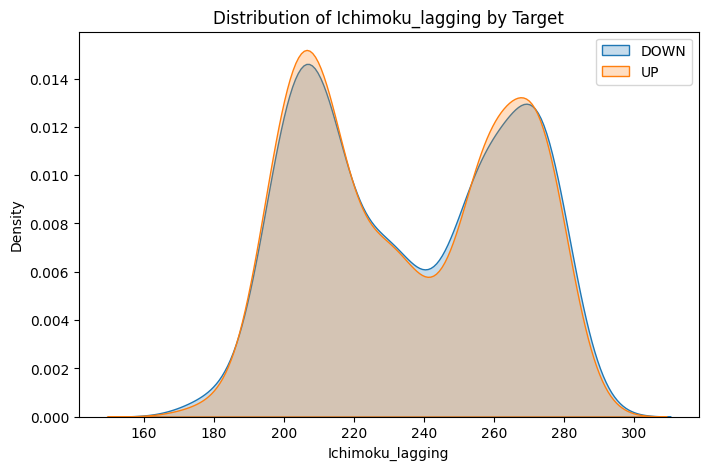

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create target & clean data
df.loc[:, 'target'] = (df['Close'].shift(-1) > df['Close']).astype(int)
df = df.dropna(subset=['target']).copy()

# 2. Iterate only through NUMERIC columns (excluding the target itself)
# This prevents errors from trying to plot 'Date' or 'Ticker' columns
numeric_cols = df.select_dtypes(include=['number']).columns

for col in numeric_cols:
    if col != 'target':
        plt.figure(figsize=(8, 5)) # Create a new figure for each plot
        
        # Check if column has data to avoid 'Dataset must contain at least two points' error
        if df[col].nunique() > 1:
            sns.kdeplot(data=df[df['target'] == 0], x=col, label='DOWN', fill=True)
            sns.kdeplot(data=df[df['target'] == 1], x=col, label='UP', fill=True)
            
            plt.title(f'Distribution of {col} by Target')
            plt.legend()
            plt.show()
        else:
            print(f"Skipping {col}: Not enough variance to plot.")

<Axes: >

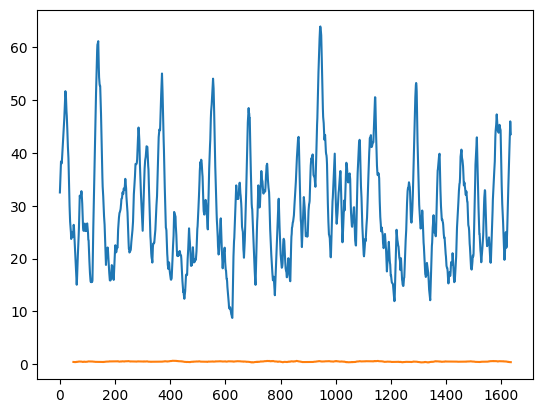

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df['ADX'].plot()
df['target'].rolling(50).mean().plot()